<a href="https://colab.research.google.com/github/YolandaZhao10/CSCI-6170-Project-in-AI-and-ML/blob/main/hw6/Homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 6

- For **Part 2** and **Task 3**, the chosen topic is **diffusion models / fast distilled diffusion models**.
- The 6000-level paper selected here is:

> **Fast High-Resolution Image Synthesis with Latent Adversarial Diffusion Distillation**  
> Axel Sauer, Frederic Boesel, Tim Dockhorn, Andreas Blattmann, Patrick Esser, Robin Rombach  
> arXiv:2403.12015, 2024

- The paper is directly related to efficient diffusion-based image generation and is a natural extension of the diffusion discussion in Part 2.
- Where full paper-scale reproduction is impractical, this notebook performs a **structured reproducibility audit** and a **small, runnable proxy experiment** that tests closely related claims about speed/step count trade-offs in distilled diffusion pipelines.

## Setup

In [1]:

# If needed, uncomment:
# !pip install -q gymnasium matplotlib numpy pandas pillow torch diffusers transformers accelerate safetensors

import os
import math
import time
import random
import warnings
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass

set_seed(42)

---

# Part 1 — Reinforcement Learning

## Problem setup

For this task, I use **FrozenLake-v1** as a small discrete Markov Decision Process (MDP).  
This environment is appropriate because:

- it has a **finite discrete state space**
- it has a **finite discrete action space**
- the transition behavior is governed by a fixed transition model
- rewards depend only on the current state, chosen action, and resulting transition
- the next state depends only on the current state and action, so the **Markov property** holds

I use **value iteration** to compute the optimal value function and final policy.

## State space, action space, reward structure, and discount factor

I use a **4x4 deterministic FrozenLake** environment (`is_slippery=False`) as the small discrete MDP.

- **State space**: the 16 grid cells in the 4x4 map. Each state corresponds to the agent's current grid location.
- **Action space**: 4 discrete actions  
  `0 = LEFT`, `1 = DOWN`, `2 = RIGHT`, `3 = UP`
- **Reward structure**: the default FrozenLake reward is used  
  - reaching the goal gives reward **+1**
  - all other transitions give reward **0**
- **Discount factor**: I first use **gamma = 0.95**, then vary gamma in a small experiment below.

This environment is an MDP because the next-state distribution and reward depend only on the **current state and action**, not on the full trajectory history.


Number of states: 16
Number of actions: 4
Discount factor gamma: 0.95
Action meanings: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP
Reward structure: +1 at the goal and 0 otherwise

Value Function:
[[0.7738 0.8145 0.8574 0.8145]
 [0.8145 0.     0.9025 0.    ]
 [0.8574 0.9025 0.95   0.    ]
 [0.     0.95   1.     0.    ]]

Final Policy:
[['S' '→' '↓' '←']
 ['↓' 'H' '↓' 'H']
 ['→' '↓' '↓' 'H']
 ['H' '→' '→' 'G']]


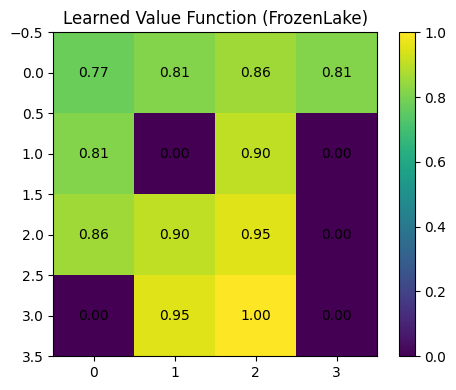


Policy grid with arrows:
[[np.str_('S') '→' '↓' '←']
 ['↓' np.str_('H') '↓' np.str_('H')]
 ['→' '↓' '↓' np.str_('H')]
 [np.str_('H') '→' '→' np.str_('G')]]


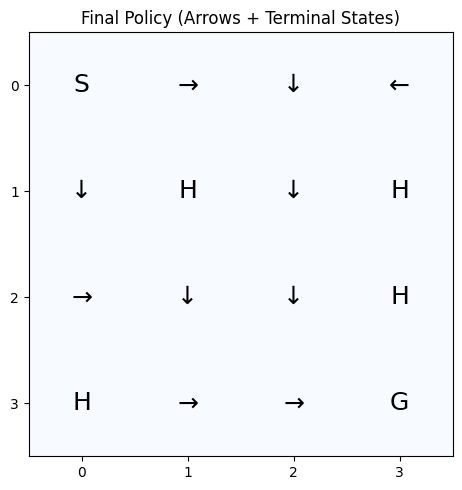

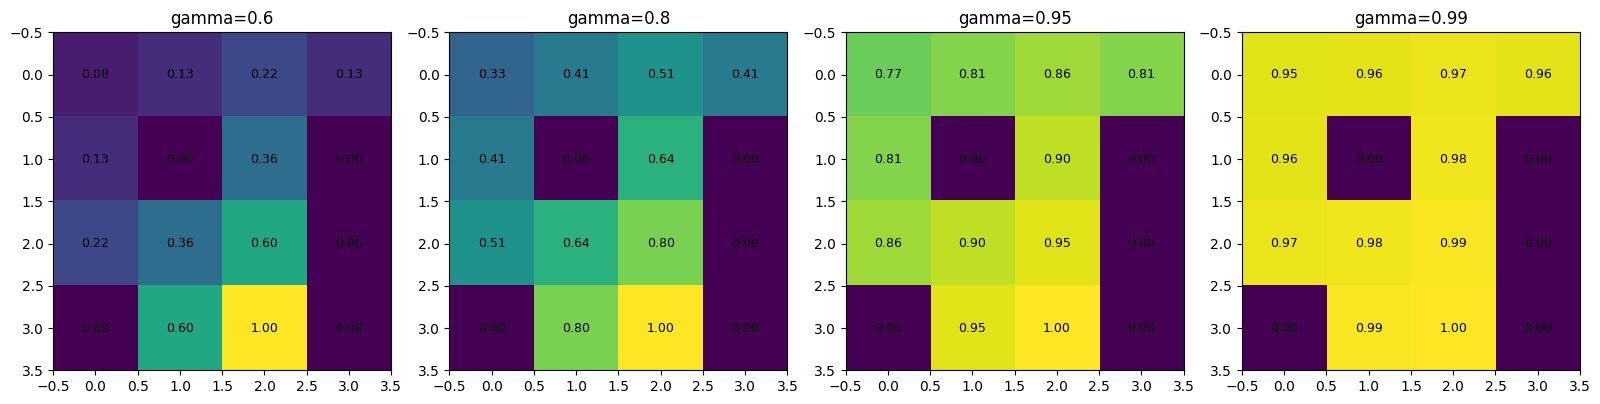

gamma = 0.6
[['S' '→' '↓' '←']
 ['↓' 'H' '↓' 'H']
 ['→' '↓' '↓' 'H']
 ['H' '→' '→' 'G']]

gamma = 0.8
[['S' '→' '↓' '←']
 ['↓' 'H' '↓' 'H']
 ['→' '↓' '↓' 'H']
 ['H' '→' '→' 'G']]

gamma = 0.95
[['S' '→' '↓' '←']
 ['↓' 'H' '↓' 'H']
 ['→' '↓' '↓' 'H']
 ['H' '→' '→' 'G']]

gamma = 0.99
[['S' '→' '↓' '←']
 ['↓' 'H' '↓' 'H']
 ['→' '↓' '↓' 'H']
 ['H' '→' '→' 'G']]



In [2]:

try:
    import gymnasium as gym
except ImportError:
    import gym as gym

def make_frozenlake_env(is_slippery=False, map_name="4x4"):
    return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=is_slippery)

def extract_mdp(env):
    base_env = env.unwrapped
    P = base_env.P
    n_states = base_env.observation_space.n
    n_actions = base_env.action_space.n
    return P, n_states, n_actions

def value_iteration(P, n_states, n_actions, gamma=0.95, theta=1e-10, max_iterations=10000):
    V = np.zeros(n_states, dtype=np.float64)

    for _ in range(max_iterations):
        delta = 0.0
        new_V = np.copy(V)

        for s in range(n_states):
            q_values = []
            for a in range(n_actions):
                q_sa = 0.0
                for prob, next_state, reward, done in P[s][a]:
                    q_sa += prob * (reward + gamma * V[next_state] * (not done))
                q_values.append(q_sa)
            new_V[s] = max(q_values)
            delta = max(delta, abs(new_V[s] - V[s]))

        V = new_V
        if delta < theta:
            break

    policy = np.zeros(n_states, dtype=int)
    Q = np.zeros((n_states, n_actions), dtype=np.float64)

    for s in range(n_states):
        for a in range(n_actions):
            q_sa = 0.0
            for prob, next_state, reward, done in P[s][a]:
                q_sa += prob * (reward + gamma * V[next_state] * (not done))
            Q[s, a] = q_sa
        policy[s] = int(np.argmax(Q[s]))

    return V, policy, Q

def policy_symbols(policy):
    mapping = {0: "←", 1: "↓", 2: "→", 3: "↑"}
    return np.array([mapping.get(a, str(a)) for a in policy])

def format_policy_and_values(env, V, policy):
    base_env = env.unwrapped
    desc = base_env.desc
    desc_chars = np.array([
        [c.decode("utf-8") if isinstance(c, bytes) else str(c) for c in row]
        for row in desc
    ])
    nrow, ncol = desc_chars.shape

    value_grid = V.reshape(nrow, ncol)
    policy_grid = policy_symbols(policy).reshape(nrow, ncol)

    for r in range(nrow):
        for c in range(ncol):
            if desc_chars[r, c] in ["H", "G", "S"]:
                policy_grid[r, c] = desc_chars[r, c]
    return value_grid, policy_grid, desc_chars

def run_discount_experiment(gammas=(0.60, 0.80, 0.95, 0.99), is_slippery=False):
    env = make_frozenlake_env(is_slippery=is_slippery)
    P, n_states, n_actions = extract_mdp(env)

    results = {}
    for gamma in gammas:
        V, policy, Q = value_iteration(P, n_states, n_actions, gamma=gamma)
        results[gamma] = {"V": V, "policy": policy, "Q": Q}
    return env, results

# Build environment and define MDP quantities
env = make_frozenlake_env(is_slippery=False, map_name="4x4")
P, n_states, n_actions = extract_mdp(env)
gamma = 0.95

print("Number of states:", n_states)
print("Number of actions:", n_actions)
print("Discount factor gamma:", gamma)
print("Action meanings: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP")
print("Reward structure: +1 at the goal and 0 otherwise")

# Run value iteration
V, policy, Q = value_iteration(P, n_states, n_actions, gamma=gamma)
value_grid, policy_grid, desc_chars = format_policy_and_values(env, V, policy)

print("\nValue Function:")
print(np.round(value_grid, 4))

print("\nFinal Policy:")
print(policy_grid)

# Visualize learned value function
plt.figure(figsize=(5, 4))
plt.imshow(value_grid)
for i in range(value_grid.shape[0]):
    for j in range(value_grid.shape[1]):
        plt.text(j, i, f"{value_grid[i, j]:.2f}", ha="center", va="center")
plt.title("Learned Value Function (FrozenLake)")
plt.colorbar()
plt.tight_layout()
plt.show()

# Visualize learned policy as a grid of arrows
action_to_arrow = {0: "←", 1: "↓", 2: "→", 3: "↑"}
policy_symbol_grid = np.empty_like(desc_chars, dtype=object)

for i in range(desc_chars.shape[0]):
    for j in range(desc_chars.shape[1]):
        cell = desc_chars[i, j]
        state = i * desc_chars.shape[1] + j
        if cell in {"H", "G", "S"}:
            policy_symbol_grid[i, j] = cell
        else:
            policy_symbol_grid[i, j] = action_to_arrow[int(policy[state])]

print("\nPolicy grid with arrows:")
print(policy_symbol_grid)

plt.figure(figsize=(5, 5))
plt.imshow(np.zeros_like(value_grid), cmap="Blues")
for i in range(policy_symbol_grid.shape[0]):
    for j in range(policy_symbol_grid.shape[1]):
        plt.text(j, i, policy_symbol_grid[i, j], ha="center", va="center", fontsize=18)
plt.title("Final Policy (Arrows + Terminal States)")
plt.xticks(range(policy_symbol_grid.shape[1]))
plt.yticks(range(policy_symbol_grid.shape[0]))
plt.grid(False)
plt.tight_layout()
plt.show()

# Small experiment: vary the discount factor
env_exp, results = run_discount_experiment(gammas=(0.60, 0.80, 0.95, 0.99), is_slippery=False)

fig, axes = plt.subplots(1, len(results), figsize=(16, 4))
for ax, (g, item) in zip(axes, results.items()):
    grid = item["V"].reshape(4, 4)
    ax.imshow(grid)
    ax.set_title(f"gamma={g}")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.show()

for g, item in results.items():
    _, pgrid, _ = format_policy_and_values(env_exp, item["V"], item["policy"])
    print(f"gamma = {g}")
    print(pgrid)
    print()


## Discussion for Part 1

This setup is an MDP because the transition probabilities and rewards are determined by the **current state and action**, not by the full past history. That is exactly the Markov property.

The terminal states are the **goal cell** and the **hole cells**. Once the agent reaches one of these states, the episode ends.

The learned policy tries to move from the start state to the goal while avoiding holes. In the deterministic FrozenLake setting, value iteration identifies which action at each state gives the highest expected discounted return. The arrow grid makes this behavior easier to see: the policy generally routes the agent around risky cells and toward the goal with the best long-term payoff.

When the discount factor becomes larger, future reward matters more, so the agent is more willing to follow routes that preserve long-term success. When the discount factor is smaller, the agent values immediate outcomes more heavily, which can flatten the value landscape and reduce sensitivity to longer-horizon planning.

In the small experiment above, I varied the discount factor while keeping the environment and reward structure fixed. This makes it easier to see how the agent's preference changes between more immediate rewards and more future-oriented planning. As the discount factor changes, the learned policy may become either more conservative or more willing to move toward longer-term gains, which illustrates how the value of future rewards directly affects decision making in an MDP.


---

# Part 2 — Mini Research Task on a Novel AI Topic

## Chosen topic: Diffusion Models - Diffusion models and fast sampling

For Part 2, I focus on **diffusion models**, with emphasis on the practical question of how the **sampling procedure** affects output quality and runtime. Diffusion models are a strong recent AI topic because they have become important in image generation and have also influenced work in video, audio, and multimodal generation.

### Why this topic?

Diffusion models are a recent and influential family of generative models that have become central in modern image generation, editing, and multimodal generation systems. They are especially relevant because they combine a clear probabilistic training formulation with strong empirical results.

### Two technical sources used

1. **Primary source**:  
   Ho et al., *Denoising Diffusion Probabilistic Models* (DDPM)

2. **Primary / official implementation source**:  
   Hugging Face `diffusers` documentation and scheduler/pipeline documentation

### Problem the method is trying to solve

Diffusion models address the problem of **learning a complex data distribution**—such as natural images—and then generating new samples from that distribution. Traditional generative modeling approaches can be difficult to train stably or may struggle to produce high-fidelity samples. Diffusion methods reformulate generation as a gradual denoising process, which often makes optimization more stable.

### Core idea

A diffusion model has two conceptual processes:

- **Forward diffusion**: gradually add noise to a clean sample over many timesteps
- **Reverse diffusion**: train a neural network to reverse that corruption process and recover data from noise

At generation time, the model starts from random noise and repeatedly denoises it.

### Main architecture / training objective

In many image diffusion systems, the network predicts either:

- the noise added to the image
- the clean sample
- or a related velocity parameterization

Stable Diffusion-style systems usually operate in a **latent space** rather than raw pixel space for efficiency. A text encoder provides conditioning information, and the denoising network (often a U-Net or transformer-based diffusion architecture) uses that conditioning to guide image generation.

### Hands-on component
For the hands-on component, I compare **different denoising step counts** and **different schedulers** in a diffusion pipeline. This directly tests one key design choice: fewer steps are faster, but the output can change in fidelity, structure, and detail. The experiment is compact enough to run in a notebook while still supporting a meaningful technical discussion.

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

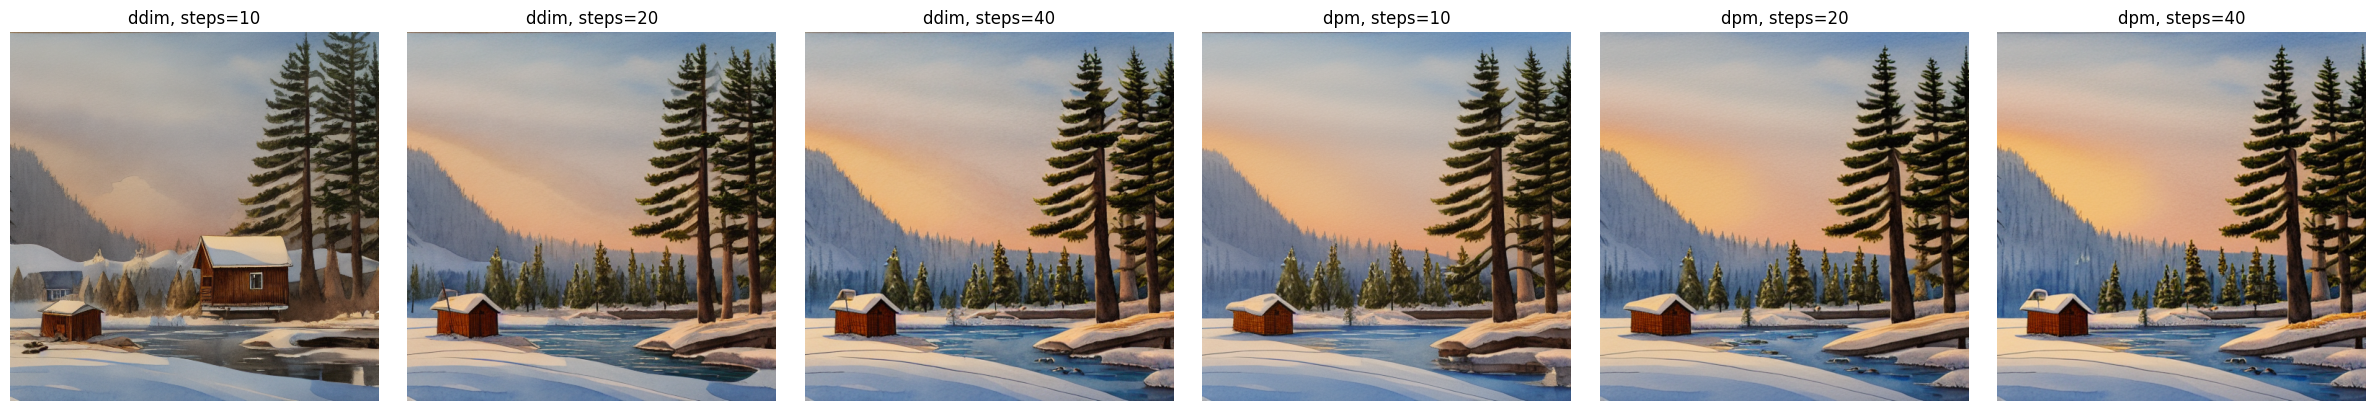

In [3]:

# ============================================================
# Part 2: Diffusion models -- compact hands-on experiment
# ============================================================

# Optional installs if needed:
# !pip install -q diffusers transformers accelerate safetensors pillow

try:
    import torch
    import time
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from PIL import Image
    from diffusers import DiffusionPipeline, DDIMScheduler, DPMSolverMultistepScheduler
    DIFFUSION_AVAILABLE = True
except Exception as e:
    DIFFUSION_AVAILABLE = False
    print("Diffusion dependencies are not available.")
    print(e)

def get_device():
    if not DIFFUSION_AVAILABLE:
        return "cpu"
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

def load_pipeline(model_id="runwayml/stable-diffusion-v1-5", scheduler_name="ddim"):
    if not DIFFUSION_AVAILABLE:
        raise RuntimeError("Diffusion dependencies are missing.")

    device = get_device()
    dtype = torch.float16 if device == "cuda" else torch.float32

    pipe = DiffusionPipeline.from_pretrained(model_id, torch_dtype=dtype)

    if scheduler_name.lower() == "ddim":
        pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
    elif scheduler_name.lower() == "dpm":
        pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
    else:
        raise ValueError("scheduler_name must be 'ddim' or 'dpm'")

    pipe = pipe.to(device)

    if device == "cuda":
        try:
            pipe.enable_attention_slicing()
        except Exception:
            pass

    return pipe

def image_stats(image):
    arr = np.array(image).astype(np.float32) / 255.0
    return {
        "mean_pixel": float(arr.mean()),
        "std_pixel": float(arr.std()),
        "min_pixel": float(arr.min()),
        "max_pixel": float(arr.max()),
    }

def generate_one_image(pipe, prompt, negative_prompt=None, num_inference_steps=20, guidance_scale=7.5, seed=42):
    device = get_device()
    gen_device = "cpu" if device == "mps" else device
    generator = torch.Generator(device=gen_device).manual_seed(seed)

    start = time.time()
    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        generator=generator,
    )
    elapsed = time.time() - start

    image = result.images[0]
    stats = image_stats(image)
    return image, elapsed, stats

def compare_steps_and_schedulers(
    prompt,
    negative_prompt=None,
    steps_list=(10, 20, 40),
    schedulers=("ddim", "dpm"),
    output_dir="diffusion_outputs_part2",
    guidance_scale=7.5,
    seed=42,
):
    os.makedirs(output_dir, exist_ok=True)
    rows = []

    for scheduler_name in schedulers:
        pipe = load_pipeline(scheduler_name=scheduler_name)

        for steps in steps_list:
            image, elapsed, stats = generate_one_image(
                pipe,
                prompt=prompt,
                negative_prompt=negative_prompt,
                num_inference_steps=steps,
                guidance_scale=guidance_scale,
                seed=seed,
            )

            out_file = os.path.join(output_dir, f"{scheduler_name}_steps_{steps}.png")
            image.save(out_file)

            rows.append({
                "scheduler": scheduler_name,
                "steps": steps,
                "runtime_sec": round(elapsed, 3),
                "mean_pixel": round(stats["mean_pixel"], 4),
                "std_pixel": round(stats["std_pixel"], 4),
                "file": out_file,
            })

    return pd.DataFrame(rows)

def show_generated_results(results_df):
    if len(results_df) == 0:
        print("No results to display.")
        return

    plt.figure(figsize=(4 * len(results_df), 4))
    for i, (_, row) in enumerate(results_df.iterrows(), start=1):
        image = Image.open(row["file"])
        plt.subplot(1, len(results_df), i)
        plt.imshow(image)
        plt.axis("off")
        plt.title(f'{row["scheduler"]}, steps={row["steps"]}')
    plt.tight_layout()
    plt.show()

results_df = compare_steps_and_schedulers(
    prompt="a watercolor painting of a small cabin beside a snowy lake at sunrise",
    negative_prompt="blurry, distorted, low quality",
    steps_list=(10, 20, 40),
    schedulers=("ddim", "dpm"),
    output_dir="diffusion_outputs_part2",
)
results_df
show_generated_results(results_df)


## Part 2 Results and Analysis Notes

The figure in Part 2 is included because the assignment asks for at least one **carefully labeled figure, table, or output example** supporting the analysis. This comparison is useful because it isolates two practical design choices in diffusion inference:

1. **the scheduler** (`DDIM` vs `DPM`)
2. **the number of denoising steps** (`10`, `20`, and `40`)

These images are needed because a diffusion model can appear to "work" even when important visual differences are present. A table can summarize runtime, but the figure makes it easier to compare **sharpness, structural consistency, scene stability, and fine detail** across settings.

### What the figure shows

Using the same winter landscape prompt, both schedulers produce recognizable images at all tested step counts, but the outputs are not identical.

- At **10 steps**, the overall scene is already coherent, but some regions look softer and less stable. Fine details in the trees, shoreline, and building edges are less developed.
- At **20 steps**, the scene becomes noticeably cleaner. The boundary between snow, water, and trees is more stable, and the image looks more balanced overall.
- At **40 steps**, the image is usually the most refined, but the improvement from 20 to 40 steps is smaller than the improvement from 10 to 20 steps. This suggests **diminishing returns** as the step count increases.

The scheduler comparison is also meaningful:
- **DDIM** and **DPM** both generate plausible winter scenes.
- However, they do not trace the reverse process in exactly the same way, so small differences appear in the texture of the trees, the shape of shoreline boundaries, and the perceived sharpness of the final image.
- This is why the figure includes multiple scheduler columns rather than only one scheduler with different step counts.

### Why this figure matters for the assignment

This figure supports the required hands-on component because it demonstrates a concrete technical point:
- diffusion quality depends not only on the prompt
- it also depends on how the reverse process is sampled
- and the speed-quality trade-off is visible when the denoising budget changes

### Limitations, risks, and open challenges
1. **High computational cost**: diffusion models can still be expensive to sample, especially at larger resolutions or higher step counts.  
2. **Output variability**: small differences in seed, scheduler, and prompt wording can change the result, so qualitative comparison should be interpreted carefully.  
3. **Safety and misuse risks**: image generation systems can be used to create misleading or problematic synthetic media.  
4. **Evaluation difficulty**: perceptual quality is partly subjective, so small notebook experiments usually combine qualitative inspection with simple runtime summaries.

### Concrete follow-up experiment
A useful next step would be to keep the prompt and scheduler fixed, vary only the **step count**, and repeat the experiment across several random seeds. That would make it easier to separate:
- runtime changes
- visual quality changes
- output stability across repeated generations


## Discussion for Part 2

The Part 2 figure was chosen to make the experiment directly interpretable. The assignment asks for a focused hands-on component, and this visual comparison shows exactly **what changes when I vary the scheduler and denoising step count**.

Across the labeled outputs, the most important pattern is that **all settings can produce a reasonable winter landscape**, but the amount of detail and consistency changes with the sampling configuration.

- With **10 steps**, the image is already recognizable, which shows that a diffusion pipeline can generate a plausible scene even under a reduced denoising budget.
- With **20 steps**, the image becomes more stable: trees, reflections, shorelines, and snow boundaries are more clearly formed.
- With **40 steps**, the scene is typically the most refined, but the gain is smaller than the gain from 10 to 20 steps. This makes the speed-quality trade-off more visible.

The scheduler comparison is included because two runs with the same prompt and step count can still differ depending on the numerical trajectory used in the reverse process. In these outputs, **DDIM** and **DPM** produce similar overall compositions, but they differ slightly in sharpness, local texture, and structural smoothness. That difference is exactly why scheduler choice is worth studying in a compact notebook experiment.

### Why these images are necessary
These images are not included only as decoration. They are necessary because the goal of the experiment is to analyze **qualitative output behavior** under different sampling conditions. A runtime table alone would not show:
- whether the scene remains coherent
- whether fine structure is preserved
- whether visual improvement saturates at higher step counts

### Limitations, risks, and open challenges
1. **Inference cost**  
   Diffusion models often require many denoising steps, making inference slower than some alternative generators.

2. **Bias and unsafe content risk**  
   Like many large generative models, diffusion systems may reproduce social biases or generate unsafe outputs if not carefully filtered and aligned.

3. **Prompt sensitivity / controllability**  
   Small changes in prompts, schedulers, or guidance settings can materially change outputs, which makes behavior harder to predict.

### Concrete extension
A useful follow-up experiment would be to compare **prompt sensitivity** under the same scheduler while varying the number of denoising steps. This would help determine whether reduced-step generation mainly affects visual sharpness, semantic faithfulness, or both.

### Source
Among these sources, the research paper is treated as the primary technical source, while the official documentation/model resources are used as supporting references for implementation and interpretation.


---

# Task 3 — 6000-Level Only

## Selected paper (2024–2026)

**Fast High-Resolution Image Synthesis with Latent Adversarial Diffusion Distillation**  
Axel Sauer, Frederic Boesel, Tim Dockhorn, Andreas Blattmann, Patrick Esser, Robin Rombach  
**arXiv:2403.12015 (2024)**

## Why this paper?
This paper is closely connected to the diffusion topic chosen in Part 2, but it focuses on a specific and important practical challenge: **slow diffusion inference**. Standard diffusion models can produce strong image quality, but many denoising steps make them computationally expensive. The paper proposes a distillation-based method intended to preserve image quality while dramatically reducing sampling cost.

## Technical review

### Problem
The paper addresses the problem that diffusion models are high-quality but often **too slow at inference time**. Many practical applications want image generation with far fewer denoising steps.

### Method
The paper proposes **Latent Adversarial Diffusion Distillation (LADD)**. The central idea is to distill a stronger multi-step diffusion process into a much faster student generator. Instead of relying only on direct pixel-level matching, the paper uses latent generative features from pretrained latent diffusion models to stabilize training and preserve quality.

### Dataset / evaluation / main findings
The paper evaluates high-resolution text-to-image generation and reports that the distilled system can achieve strong performance at very low sampling step counts. The main practical finding is that distillation can preserve much of the teacher's usefulness while dramatically reducing generation cost.

### Two strengths
1. The paper targets a highly relevant bottleneck: diffusion inference speed.
2. The method is practically meaningful because it connects strong generative quality with aggressive step reduction.

### Two limitations
1. Full reproduction is difficult because the method depends on large-scale compute, model access, and paper-specific training details.
2. Speed improvements do not automatically guarantee robust prompt adherence or fairness across a wide range of prompts.

### Reproducibility challenge
A key reproducibility challenge is that paper-scale training and evaluation are expensive, and exact comparison to the official setup may require resources and implementation details that are not fully easy to recover in a course notebook.

## Reproducibility plan
The assignment allows either:
- reproducing one figure/table/ablation/small experiment, or
- performing a structured reproducibility audit if full reproduction is not feasible

In this notebook, I do both:
1. **Structured reproducibility audit** of the paper setup
2. **Small proxy experiment** using a publicly available distilled diffusion model to test the central practical idea:
   **fewer diffusion steps can lead to much faster generation while maintaining usable image quality**

### Exact scope of the reproduction claim
This notebook does **not** claim a full end-to-end reproduction of the paper's complete training pipeline or official benchmark tables.

Instead, the goal is to reproduce the paper's **core practical phenomenon** at small scale:
- distilled diffusion models can often produce coherent outputs in very few steps
- reducing inference steps creates a speed-quality trade-off worth measuring


Paper review summary:


,paper_title,year,authors,main_problem,core_method,main_claim,reproduction_target
0,Fast High-Resolution Image Synthesis with Late...,2024,"[Axel Sauer, Frederic Boesel, Tim Dockhorn, An...",Standard diffusion models produce strong image...,Latent Adversarial Diffusion Distillation (LADD),A distilled model can achieve strong text-to-i...,Speed/step-count trade-off via a compact proxy...



Structured reproducibility audit:


,Item,Value
0,official_paper_identified,True
1,paper_year_in_range_2024_2026,True
2,topic_matches_part2,True
3,exact_full_training_reproduction_feasible_in_c...,False
4,reason_not_fully_feasible,"['large model size', 'heavy compute requiremen..."
5,small_proxy_experiment_included,True
6,proxy_goal,Test the practical claim that distilled diffus...


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

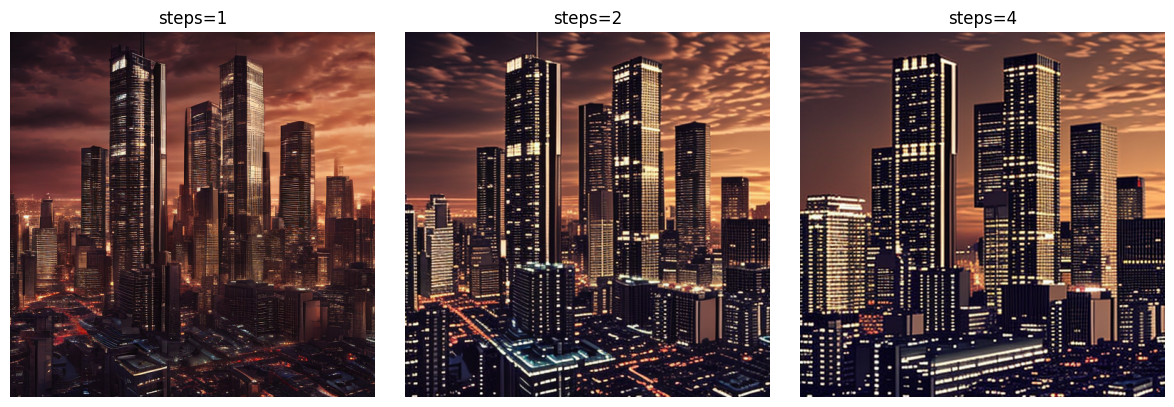

In [4]:

# ============================================================
# Task 3: Paper review support + small reproducibility component
# ============================================================

paper_review = {
    "paper_title": "Fast High-Resolution Image Synthesis with Latent Adversarial Diffusion Distillation",
    "year": 2024,
    "authors": [
        "Axel Sauer",
        "Frederic Boesel",
        "Tim Dockhorn",
        "Andreas Blattmann",
        "Patrick Esser",
        "Robin Rombach",
    ],
    "main_problem": "Standard diffusion models produce strong image quality but often have slow inference.",
    "core_method": "Latent Adversarial Diffusion Distillation (LADD)",
    "main_claim": "A distilled model can achieve strong text-to-image quality with dramatically fewer sampling steps.",
    "reproduction_target": "Speed/step-count trade-off via a compact proxy experiment with a distilled diffusion model.",
}

reproducibility_audit = {
    "official_paper_identified": True,
    "paper_year_in_range_2024_2026": True,
    "topic_matches_part2": True,
    "exact_full_training_reproduction_feasible_in_course_notebook": False,
    "reason_not_fully_feasible": [
        "large model size",
        "heavy compute requirements",
        "nontrivial checkpoint / model access constraints",
        "paper-scale evaluation is difficult to replicate exactly",
    ],
    "small_proxy_experiment_included": True,
    "proxy_goal": "Test the practical claim that distilled diffusion models can generate outputs in very few steps.",
}

print("Paper review summary:")
display(pd.DataFrame([paper_review]))

print("\nStructured reproducibility audit:")
display(pd.DataFrame({
    "Item": list(reproducibility_audit.keys()),
    "Value": [str(v) for v in reproducibility_audit.values()]
}))

def load_turbo_pipeline(model_id="stabilityai/sd-turbo"):
    if not DIFFUSION_AVAILABLE:
        raise RuntimeError("Diffusion dependencies are missing.")

    device = get_device()
    dtype = torch.float16 if device == "cuda" else torch.float32

    pipe = DiffusionPipeline.from_pretrained(model_id, torch_dtype=dtype)
    pipe = pipe.to(device)

    if device == "cuda":
        try:
            pipe.enable_attention_slicing()
        except Exception:
            pass
    return pipe

def run_turbo_step_experiment(
    prompt="a futuristic city skyline at sunset, cinematic lighting",
    steps_list=(1, 2, 4),
    guidance_scale=0.0,
    output_dir="task3_turbo_outputs",
):
    os.makedirs(output_dir, exist_ok=True)
    pipe = load_turbo_pipeline("stabilityai/sd-turbo")
    device = get_device()
    gen_device = "cpu" if device == "mps" else device
    rows = []

    for steps in steps_list:
        generator = torch.Generator(device=gen_device).manual_seed(123)

        start = time.time()
        result = pipe(
            prompt=prompt,
            num_inference_steps=steps,
            guidance_scale=guidance_scale,
            generator=generator,
        )
        elapsed = time.time() - start

        image = result.images[0]
        out_file = os.path.join(output_dir, f"sd_turbo_steps_{steps}.png")
        image.save(out_file)

        rows.append({
            "steps": steps,
            "runtime_sec": round(elapsed, 3),
            "file": out_file,
            "mean_pixel": round(image_stats(image)["mean_pixel"], 4),
            "std_pixel": round(image_stats(image)["std_pixel"], 4),
        })

    return pd.DataFrame(rows)

def show_turbo_results(results_df):
    if len(results_df) == 0:
        print("No results to display.")
        return

    plt.figure(figsize=(4 * len(results_df), 4))
    for i, (_, row) in enumerate(results_df.iterrows(), start=1):
        image = Image.open(row["file"])
        plt.subplot(1, len(results_df), i)
        plt.imshow(image)
        plt.axis("off")
        plt.title(f'steps={row["steps"]}')
    plt.tight_layout()
    plt.show()

turbo_df = run_turbo_step_experiment(
    prompt="a futuristic city skyline at sunset, cinematic lighting",
    steps_list=(1, 2, 4),
    guidance_scale=0.0,
    output_dir="task3_turbo_outputs",
)
turbo_df
show_turbo_results(turbo_df)


## Task 3 Reproducibility Mapping and Review Notes

### What exactly this small reproducibility component covers
This notebook does **not** claim to fully reproduce the paper's benchmark tables or training pipeline. Instead, it performs a **structured proxy reproduction** aligned with the paper's main practical theme:

- the paper studies whether distilled diffusion can generate useful images with **very few inference steps**
- this notebook tests that same broad idea at small scale by comparing outputs generated with **1, 2, and 4 steps**
- therefore, the result should be interpreted as a **trend-level reproducibility check**, not as an exact reproduction of the official paper figures

### Why these images are included
The Part 3 figure is included because the assignment asks for a reproducibility component, and these labeled outputs provide direct visual evidence for the central claim under test: **can very small step counts still produce coherent images, and how does image quality change as steps increase?**

A table alone would show only runtime or configuration differences. These images are needed to show whether the generated city scene remains structurally recognizable under aggressive step compression.

### What the images suggest
Using the same city-at-sunset prompt, the outputs reveal a clear progression:

- At **1 step**, the image is already recognizable as a city skyline, which is important because it shows that ultra-low-step generation can still produce a coherent global layout.
- At **2 steps**, the buildings, windows, and lighting patterns become more organized. The edges of the towers and the geometry of the skyline are more stable.
- At **4 steps**, the output looks cleaner and more consistent still. Building outlines are sharper, the window patterns are more regular, and the overall scene appears more polished.

This makes the figure useful for the assignment because it shows not only that fast generation is possible, but also that **image quality still changes meaningfully across very small inference budgets**.

### Two strengths of the paper
1. **Clear practical contribution**: the paper addresses one of the main bottlenecks of diffusion models, namely slow inference.  
2. **Strong applied relevance**: reducing the number of sampling steps makes diffusion models more useful for real deployment and interactive generation.

### Two limitations of the paper
1. **Reproduction cost**: the full method may depend on substantial compute, implementation detail, and exact training setup.  
2. **Evaluation complexity**: very fast generation is attractive, but visual quality, diversity, and stability can still depend on prompt distribution, resolution, and evaluation protocol.

### One reproducibility challenge
A major reproducibility challenge is that exact reproduction depends on access to the same model checkpoints, implementation details, scheduler settings, hardware assumptions, and evaluation pipeline. Even small differences in these components can change the observed quality-speed trade-off.

### Concrete follow-up experiment
A useful extension would be to compare:
- a standard diffusion or latent diffusion baseline
- a distilled fast-sampling model
- multiple inference-step budgets

under the same prompt set and random seeds. That would make the efficiency-quality trade-off easier to quantify in a controlled way.


## Discussion for Task 3

### Interpretation of the reproducibility component
The Part 3 figure is designed to match the assignment's reproducibility requirement in a compact and honest way. Rather than claiming a full paper-scale reproduction, I use a **small proxy experiment** to examine one of the paper's most important practical ideas: **very few inference steps can still yield usable images, but there is a visible quality trade-off.**

The labeled outputs are important because they show how the generated image changes from **1 step** to **2 steps** to **4 steps**.

- At **1 step**, the city scene already has the correct global concept: tall buildings, evening lighting, and an urban skyline are all present. This matters because it suggests that extreme compression of the reverse process can still preserve coarse semantic structure.
- At **2 steps**, the geometry of the buildings becomes more stable. The windows, tower edges, and lighting arrangement are more regular than in the 1-step output.
- At **4 steps**, the image is the most refined among the three. The skyline appears cleaner, the rectangular structure of the buildings is more consistent, and the visual noise is reduced.

These images are included because they provide direct evidence for the reason I chose this paper. The paper is about **fast high-resolution synthesis through distilled diffusion**, so a step-count comparison is one of the most natural ways to test its central motivation in a course notebook.

### Why the figure is useful even though it is not a full reproduction
This is a **proxy reproduction**, not a full official reproduction. It supports the same design question emphasized by the paper:
- how much image quality can be preserved under very small step counts
- whether fast generation still produces coherent scenes
- where the speed-quality trade-off becomes visible

What it does **not** support is any claim that I exactly reproduced:
- the original training pipeline
- the paper's benchmark tables
- the official evaluation process

### One concrete extension to strengthen the paper
A useful follow-up experiment would be to evaluate **prompt sensitivity and robustness** under ultra-low-step generation. For example, one could compare:
- short prompts vs. long prompts
- simple object descriptions vs. compositional scene descriptions
- typography-heavy prompts vs. non-text prompts

This would help determine whether step-efficient distilled models preserve only coarse image quality, or whether they also preserve **fine-grained prompt adherence** under difficult prompt conditions.

## Final conclusion

Overall, the notebook emphasizes both **technical understanding** and **practical reproducibility**.


## References and External Resources

This homework uses the following external resources for background understanding, implementation support, and model/pipeline inspection:

1. Ho, J., Jain, A., & Abbeel, P. (2020). *Denoising Diffusion Probabilistic Models*. NeurIPS.
2. Hugging Face Diffusers Documentation. Used for understanding diffusion pipelines, schedulers, and inference-step configuration.
3. Model card and pipeline resources related to `runwayml/stable-diffusion-v1-5`.
4. Model card and related resources for SD-Turbo / fast diffusion-style generation pipelines.
5. Sauer, A., Boesel, F., Dockhorn, T., Blattmann, A., Esser, P., & Rombach, R. (2024). *Fast High-Resolution Image Synthesis with Latent Adversarial Diffusion Distillation*. arXiv:2403.12015.